<a href="https://colab.research.google.com/github/Shervinrtd/Chest_Xray/blob/main/Chest_Xray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision torchaudio
!pip install matplotlib seaborn scikit-learn
!pip install opencv-python

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Device: cuda
GPU Name: Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

zip_path = '/content/drive/MyDrive/deep_learning_project/chest_xray.zip'
extract_path = '/content/chest_xray'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os

print(os.listdir('/content/chest_xray/chest_xray/train'))

['NORMAL', 'PNEUMONIA']


**Import Required Libraries**

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import os

**Check GPU**

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


**Define Image Transformations**

In [10]:
import torch
from torch.utils.data import random_split

# Reproducibility
torch.manual_seed(42)

# Transforms
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Full training dataset
full_dataset = datasets.ImageFolder(
    root='/content/chest_xray/chest_xray/train',
    transform=train_transform
)

# Split sizes
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Create train/validation split
train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

# Test dataset remains untouched
test_dataset = datasets.ImageFolder(
    root='/content/chest_xray/chest_xray/test',
    transform=test_transform
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 4172
Validation size: 1044
Test size: 624


**Visualize a Batch**

Verify:

*   images display correctly,
*   no distortions,



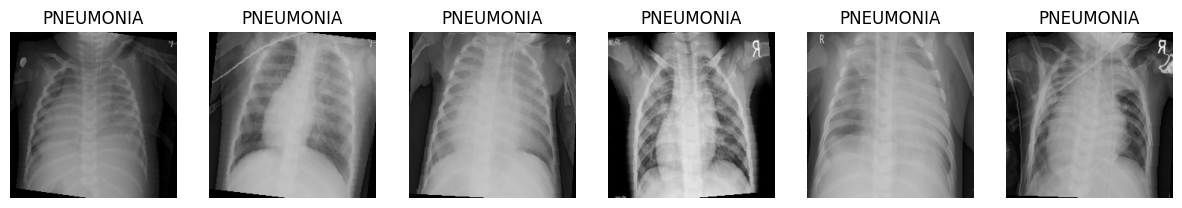

In [14]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.clip

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 6, figsize=(15,5))

for i in range(6):

    img = images[i].permute(1, 2, 0).numpy()

    img = (img * 0.5) + 0.5 # Unnormalize images

    img = np.clip(img, 0, 1)

    axes[i].imshow(img)

    # Display the actual class name, using full_dataset.classes
    axes[i].set_title(full_dataset.classes[labels[i].item()])

    axes[i].axis('off')

plt.show()

**Build the Baseline CNN**

In [16]:
import torch.nn as nn

class PneumoniaCNN(nn.Module):

    def __init__(self):

        super(PneumoniaCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256 * 14 * 14, 512),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, 2)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

**Initialize Model**

In [17]:
model = PneumoniaCNN().to(device)

print(model)

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

**Create Weighted Loss**





In [18]:
from collections import Counter

train_labels = [label for _, label in train_dataset]

class_counts = Counter(train_labels)

print(class_counts)

Counter({1: 3114, 0: 1058})


**Create Proper Class Weights**

In [19]:
total_samples = class_counts[0] + class_counts[1]

weight_normal = total_samples / (2 * class_counts[0])
weight_pneumonia = total_samples / (2 * class_counts[1])

weights = torch.tensor(
    [weight_normal, weight_pneumonia],
    dtype=torch.float
).to(device)

print(weights)

tensor([1.9716, 0.6699], device='cuda:0')


**Define Loss + Optimizer**

In [20]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

**Training Loop**

In [21]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=20,
    patience=3
):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    best_val_loss = float('inf')

    early_stop_counter = 0

    for epoch in range(epochs):

        # TRAINING
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)

        train_accuracy = 100 * correct / total

        # VALIDATION
        model.eval()

        val_running_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)

                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)

        val_accuracy = 100 * val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")

        # CHECKPOINT
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(model.state_dict(), "best_baseline_cnn.pth")

            print("Best model saved!")

            early_stop_counter = 0

        else:

            early_stop_counter += 1

            print(f"No improvement count: {early_stop_counter}")

        # EARLY STOPPING
        if early_stop_counter >= patience:

            print("Early stopping triggered!")

            break

        print("-" * 50)

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

**Training**

In [22]:
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=20,
    patience=3
)

Epoch [1/20]
Train Loss: 1.7043 | Train Accuracy: 85.00%
Val Loss: 0.1659 | Val Accuracy: 92.53%
Best model saved!
--------------------------------------------------
Epoch [2/20]
Train Loss: 0.1664 | Train Accuracy: 93.53%
Val Loss: 0.1121 | Val Accuracy: 94.92%
Best model saved!
--------------------------------------------------
Epoch [3/20]
Train Loss: 0.1556 | Train Accuracy: 94.53%
Val Loss: 0.1094 | Val Accuracy: 95.40%
Best model saved!
--------------------------------------------------
Epoch [4/20]
Train Loss: 0.1583 | Train Accuracy: 94.08%
Val Loss: 0.1613 | Val Accuracy: 91.19%
No improvement count: 1
--------------------------------------------------
Epoch [5/20]
Train Loss: 0.1581 | Train Accuracy: 94.08%
Val Loss: 0.1400 | Val Accuracy: 95.79%
No improvement count: 2
--------------------------------------------------
Epoch [6/20]
Train Loss: 0.1519 | Train Accuracy: 94.56%
Val Loss: 0.1766 | Val Accuracy: 95.50%
No improvement count: 3
Early stopping triggered!


**Load Best Model**

In [23]:
model.load_state_dict(torch.load("best_baseline_cnn.pth"))

<All keys matched successfully>

**Evaluate on Test Set**

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

**Classification Report**

In [25]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=['NORMAL', 'PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.96      0.48      0.64       234
   PNEUMONIA       0.76      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.86      0.74      0.75       624
weighted avg       0.83      0.80      0.78       624



**Confusion Matrix**

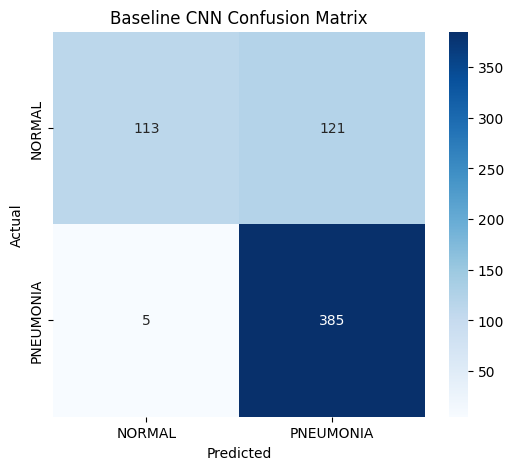

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline CNN Confusion Matrix")

plt.show()

**Reinitialize Model**

In [27]:
model = PneumoniaCNN().to(device)

**Use Weighted Loss**

In [28]:
criterion = nn.CrossEntropyLoss(weight=weights)

**Recreate Optimizer**

In [29]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

**Train Weighted CNN**

In [30]:
train_losses_weighted, val_losses_weighted, train_acc_weighted, val_acc_weighted = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=20,
    patience=3
)

Epoch [1/20]
Train Loss: 2.1481 | Train Accuracy: 82.26%
Val Loss: 0.1928 | Val Accuracy: 92.72%
Best model saved!
--------------------------------------------------
Epoch [2/20]
Train Loss: 0.2297 | Train Accuracy: 91.16%
Val Loss: 0.1442 | Val Accuracy: 95.88%
Best model saved!
--------------------------------------------------
Epoch [3/20]
Train Loss: 0.1726 | Train Accuracy: 93.02%
Val Loss: 0.1027 | Val Accuracy: 96.17%
Best model saved!
--------------------------------------------------
Epoch [4/20]
Train Loss: 0.1745 | Train Accuracy: 93.62%
Val Loss: 0.1399 | Val Accuracy: 93.39%
No improvement count: 1
--------------------------------------------------
Epoch [5/20]
Train Loss: 0.1492 | Train Accuracy: 94.30%
Val Loss: 0.0894 | Val Accuracy: 96.26%
Best model saved!
--------------------------------------------------
Epoch [6/20]
Train Loss: 0.1677 | Train Accuracy: 94.25%
Val Loss: 0.0962 | Val Accuracy: 95.69%
No improvement count: 1
-------------------------------------------

**Load Best Weighted CNN**

In [31]:
model.load_state_dict(torch.load("best_baseline_cnn.pth"))

<All keys matched successfully>

**Evaluate Weighted CNN on the test set**

In [32]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

**Classification Report**

In [33]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=['NORMAL', 'PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.92      0.57      0.71       234
   PNEUMONIA       0.79      0.97      0.87       390

    accuracy                           0.82       624
   macro avg       0.86      0.77      0.79       624
weighted avg       0.84      0.82      0.81       624



**Confusion Matrix**

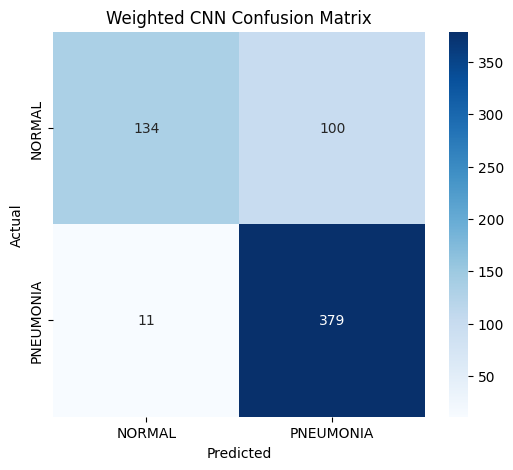

In [34]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Weighted CNN Confusion Matrix")

plt.show()

# Transfer Learning

**Import ResNet**

In [35]:
from torchvision import models

**Load Pretrained ResNet50**

In [36]:
resnet_model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 94.5MB/s]


**Freeze Most Layers**

In [37]:
for param in resnet_model.parameters():
    param.requires_grad = False

**Unfreeze LAST BLOCK**

This allows:


*   high-level feature adaptation
*   while keeping most pretrained knowledge stable



In [38]:
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

**Replace Final Classifier**

In [39]:
num_features = resnet_model.fc.in_features

resnet_model.fc = nn.Sequential(

    nn.Linear(num_features, 256),

    nn.ReLU(),

    nn.Dropout(0.5),

    nn.Linear(256, 2)
)

**Move Model to GPU**

In [40]:
resnet_model = resnet_model.to(device)

**Define Weighted Loss**

In [41]:
criterion = nn.CrossEntropyLoss(weight=weights)

**Smaller Fine-Tuning Learning Rate**

In [42]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=0.00005
)

**Add Learning Rate Scheduler**

*   LR automatically decreases
*   training stabilizes



In [43]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=1
)

**Training Loop**

In [44]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None,
    epochs=20,
    patience=3,
    save_path="best_model.pth"
):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    best_val_loss = float('inf')

    early_stop_counter = 0

    for epoch in range(epochs):

        # TRAINING
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)

        train_accuracy = 100 * correct / total

        # VALIDATION
        model.eval()

        val_running_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)

                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)

        val_accuracy = 100 * val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")

        # Scheduler
        if scheduler:
            scheduler.step(val_loss)

        # CHECKPOINT
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(model.state_dict(), save_path)

            print("Best model saved!")

            early_stop_counter = 0

        else:

            early_stop_counter += 1

            print(f"No improvement count: {early_stop_counter}")

        # EARLY STOPPING
        if early_stop_counter >= patience:

            print("Early stopping triggered!")

            break

        print("-" * 50)

    return (
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

**Train Fine-Tuned ResNet50**

In [45]:
train_losses_resnet, val_losses_resnet, train_acc_resnet, val_acc_resnet = train_model(
    resnet_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=20,
    patience=4,
    save_path="best_resnet50.pth"
)

Epoch [1/20]
Train Loss: 0.1929 | Train Accuracy: 91.44%
Val Loss: 0.0852 | Val Accuracy: 97.51%
Best model saved!
--------------------------------------------------
Epoch [2/20]
Train Loss: 0.0822 | Train Accuracy: 97.27%
Val Loss: 0.0867 | Val Accuracy: 96.65%
No improvement count: 1
--------------------------------------------------
Epoch [3/20]
Train Loss: 0.0633 | Train Accuracy: 97.56%
Val Loss: 0.0771 | Val Accuracy: 98.18%
Best model saved!
--------------------------------------------------
Epoch [4/20]
Train Loss: 0.0565 | Train Accuracy: 98.08%
Val Loss: 0.0623 | Val Accuracy: 97.70%
Best model saved!
--------------------------------------------------
Epoch [5/20]
Train Loss: 0.0532 | Train Accuracy: 98.08%
Val Loss: 0.0666 | Val Accuracy: 98.08%
No improvement count: 1
--------------------------------------------------
Epoch [6/20]
Train Loss: 0.0372 | Train Accuracy: 98.56%
Val Loss: 0.0654 | Val Accuracy: 97.32%
No improvement count: 2
-------------------------------------

**Load Best ResNet**

In [46]:
resnet_model.load_state_dict(torch.load("best_resnet50.pth"))

<All keys matched successfully>

**Evaluate Fine-Tuned ResNet50 on the test set**

In [47]:
resnet_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

**Classification Report**

In [48]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=['NORMAL', 'PNEUMONIA']
))

              precision    recall  f1-score   support

      NORMAL       0.98      0.52      0.68       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624



**Confusion Matrix**

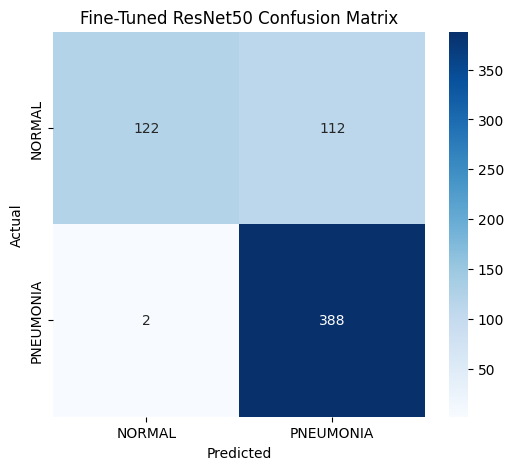

In [49]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fine-Tuned ResNet50 Confusion Matrix")

plt.show()

Although transfer learning with ResNet50 achieved extremely high pneumonia sensitivity, the weighted CNN provided more balanced classification performance on the test set.”

**K-Fold Cross Validation on Weighted CNN**

**Import KFold**

In [50]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score

**Create Full Dataset Again**

In [52]:
full_dataset = datasets.ImageFolder(
    root='/content/chest_xray/chest_xray/train',
    transform=train_transform
)

**Create KFold Object**

In [53]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

**Prepare Fold Tracking**

In [54]:
fold_results = []

**K-Fold Training Loop**

In [ ]:
for fold, (train_ids, val_ids) in enumerate(kfold.split(full_dataset)):

    print(f"\n========== Fold {fold+1} ==========")

    # Create subsets
    train_subsampler = torch.utils.data.Subset(full_dataset, train_ids)
    val_subsampler = torch.utils.data.Subset(full_dataset, val_ids)

    # DataLoaders
    train_loader = DataLoader(
        train_subsampler,
        batch_size=32,
        shuffle=True
    )

    val_loader = DataLoader(
        val_subsampler,
        batch_size=32,
        shuffle=False
    )

    # Model
    model = PneumoniaCNN().to(device)

    # Compute class weights for THIS fold
    train_labels = [full_dataset.targets[i] for i in train_ids]

    class_counts = Counter(train_labels)

    total_samples = class_counts[0] + class_counts[1]

    weight_normal = total_samples / (2 * class_counts[0])
    weight_pneumonia = total_samples / (2 * class_counts[1])

    weights = torch.tensor(
        [weight_normal, weight_pneumonia],
        dtype=torch.float
    ).to(device)

    # Loss
    criterion = nn.CrossEntropyLoss(weight=weights)

    # Optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    # Train for FEWER epochs (important for runtime)
    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        epochs=10,
        patience=2,
        save_path=f"best_fold_{fold+1}.pth"
    )

    # Load best fold model
    model.load_state_dict(
        torch.load(f"best_fold_{fold+1}.pth")
    )

    # Validation evaluation
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Metrics
    acc = accuracy_score(all_labels, all_preds)

    f1 = f1_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    fold_results.append({
        "fold": fold + 1,
        "accuracy": acc,
        "f1_score": f1
    })

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    print(f"Fold {fold+1} Weighted F1: {f1:.4f}")


========== Fold 1 ==========
Epoch [1/10]
Train Loss: 1.2774 | Train Accuracy: 87.30%
Val Loss: 0.1135 | Val Accuracy: 95.40%
Best model saved!
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.1744 | Train Accuracy: 93.50%
Val Loss: 0.0995 | Val Accuracy: 95.88%
Best model saved!
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.1611 | Train Accuracy: 94.20%
Val Loss: 0.0981 | Val Accuracy: 96.36%
Best model saved!
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.1388 | Train Accuracy: 94.68%
Val Loss: 0.0987 | Val Accuracy: 95.98%
No improvement count: 1
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.1418 | Train Accuracy: 95.33%
Val Loss: 0.0914 | Val Accuracy: 95.98%
Best model saved!
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.1208 | Train Accuracy: 96.09%
Val Loss: 0.0736 | Val Accuracy: 96.84%
Best model saved!
-------------------

**Final Summary**

In [ ]:
accuracies = [x['accuracy'] for x in fold_results]
f1_scores = [x['f1_score'] for x in fold_results]

print("Average Accuracy:", np.mean(accuracies))
print("Accuracy Std:", np.std(accuracies))

print("Average Weighted F1:", np.mean(f1_scores))
print("F1 Std:", np.std(f1_scores))

In [ ]:
class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_image, target_class=None):

        output = self.model(input_image)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()

        loss = output[:, target_class]

        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        cam = cam.detach().cpu().numpy()

        cam = cv2.resize(cam, (224, 224))

        cam = (cam - cam.min()) / (cam.max() - cam.min())

        return cam

**Select Target Layer**

In [ ]:
target_layer = model.features[-2]

grad_cam = GradCAM(model, target_layer)

**Get a Test Image**

In [ ]:
image, label = test_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

**Generate Heatmap**

In [ ]:
cam = grad_cam.generate_cam(input_tensor)

**Convert Original Image**

In [ ]:
original_image = image.permute(1, 2, 0).numpy()

original_image = (original_image * 0.5) + 0.5

original_image = np.clip(original_image, 0, 1)

**Overlay Heatmap**

In [ ]:
heatmap = cv2.applyColorMap(
    np.uint8(255 * cam),
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

heatmap = heatmap / 255.0

overlay = heatmap * 0.4 + original_image * 0.6

**Display Results**

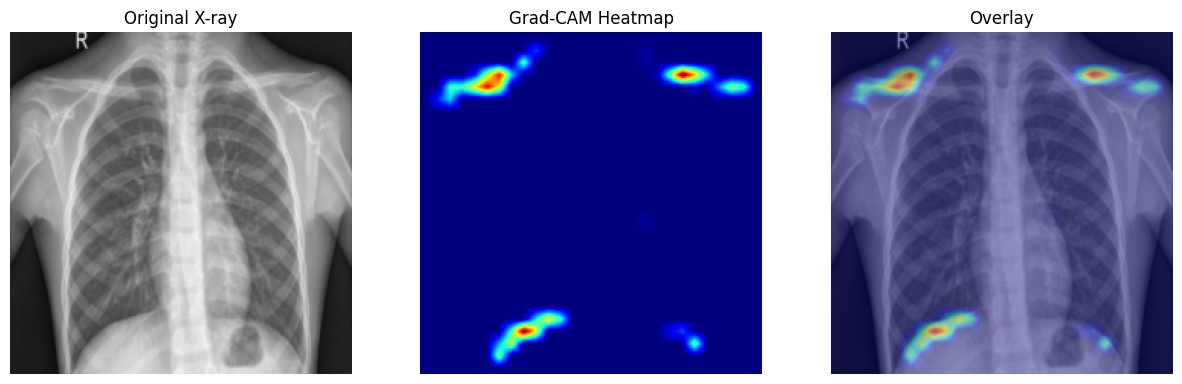

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(original_image)
axes[0].set_title("Original X-ray")
axes[0].axis('off')

axes[1].imshow(cam, cmap='jet')
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.show()

**Loss Curve**

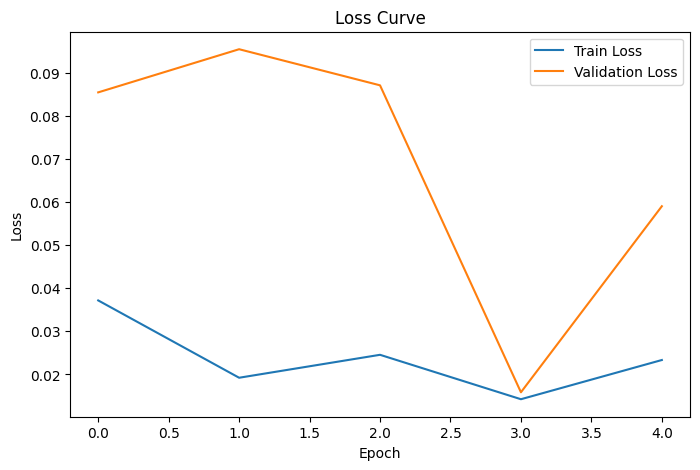

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses_resnet_ft, label='Train Loss')
plt.plot(val_losses_resnet_ft, label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

**Accuracy Curve**

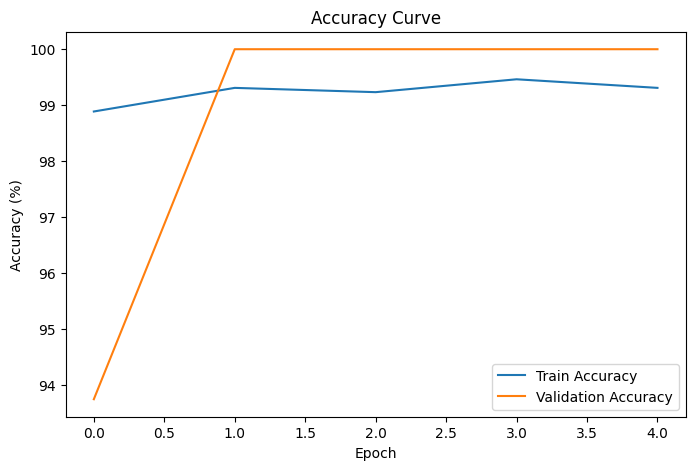

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_acc_resnet_ft, label='Train Accuracy')
plt.plot(val_acc_resnet_ft, label='Validation Accuracy')

plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.legend()

plt.show()